# Procesamiento Digital de Imágenes
## Guía de Trabajos Prácticos 5 — Procesamiento y filtrado frecuencial
**FICH, UNL — Ingeniería Informática**

## EJERCICIO 1

--PUNTOS 1 Y 2: Formas basicas y TDF


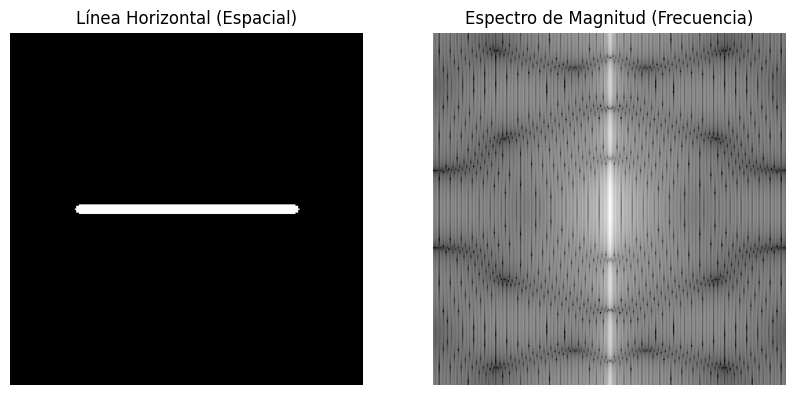

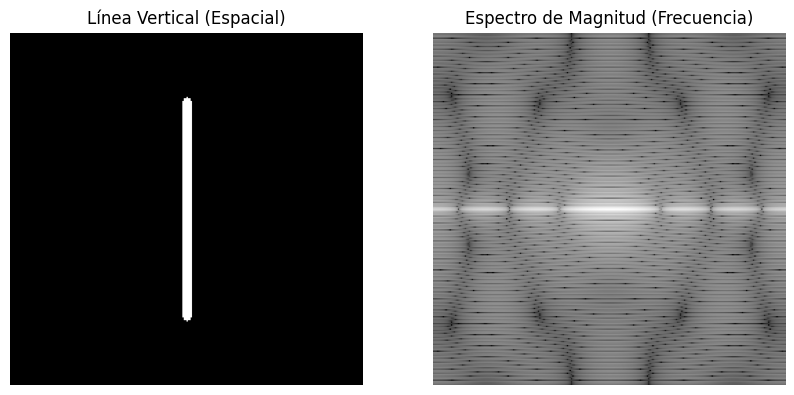

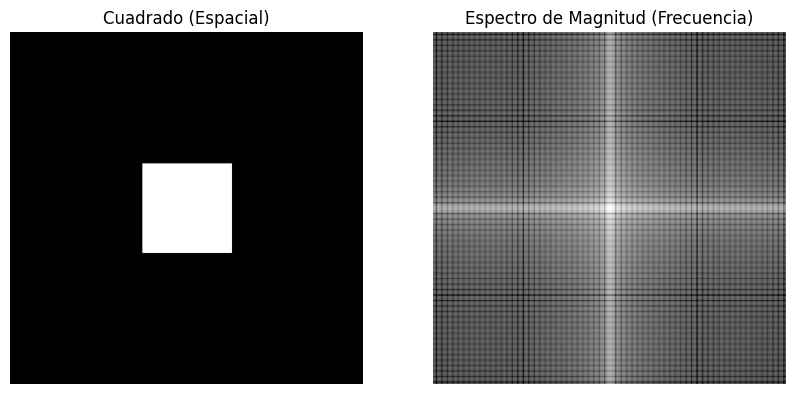

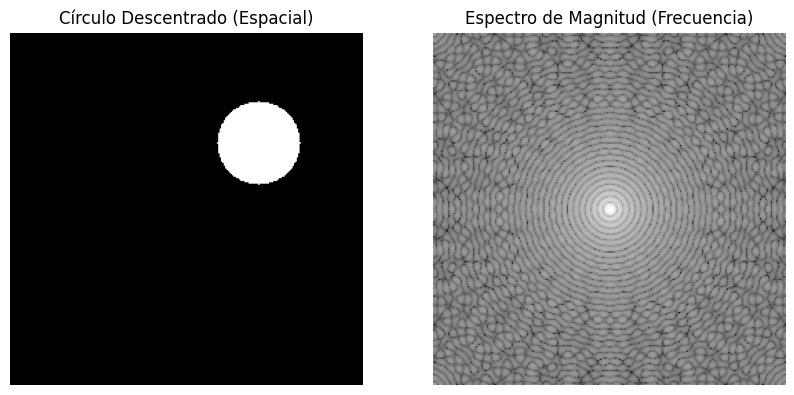


--- PUNTO 3: Rotación y Fenómenos de Borde ---


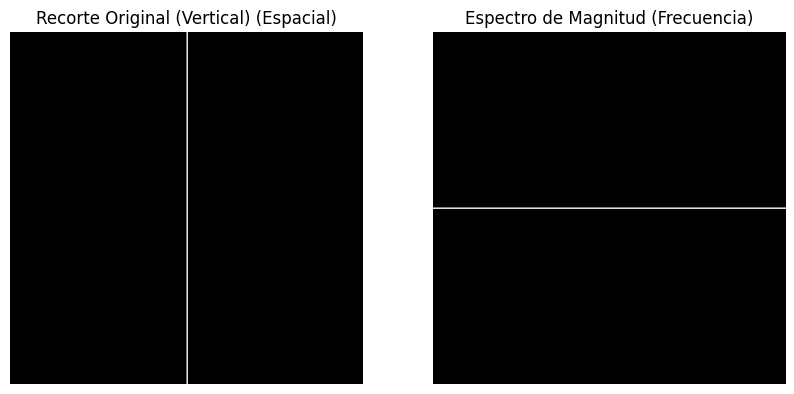

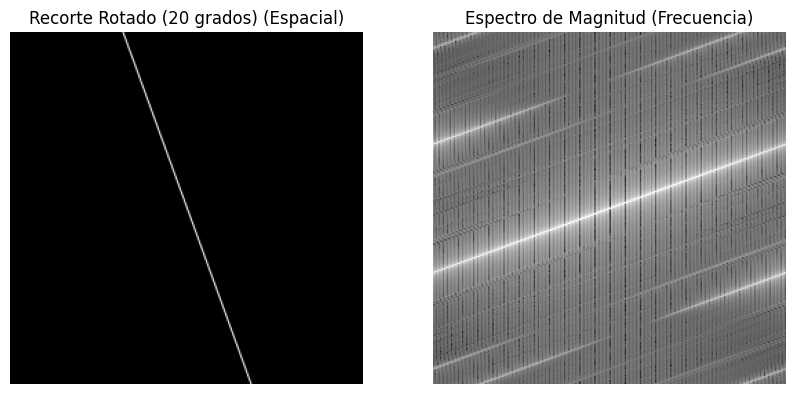

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils

def calcular_y_mostrar_fft(img_espacial,titulo):
    # 1. Calcular la FFT de la imagen
    f = np.fft.fft2(img_espacial)
    # 2. Centrar las bajas frecuencias
    fshift = np.fft.fftshift(f)
    # 3. Calcular magnitud y aplicar logaritmo (sumamos 1 para no hacer log(0))
    magnitud = 20 * np.log(np.abs(fshift) + 1)
    
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_espacial, cmap='gray')
    axs[0].set_title(titulo + " (Espacial)")
    axs[0].axis('off')
    
    axs[1].imshow(magnitud, cmap='gray')
    axs[1].set_title("Espectro de Magnitud (Frecuencia)")
    axs[1].axis('off')
    plt.show()

print('--PUNTOS 1 Y 2: Formas basicas y TDF')

#Crear lienzo negros de 256x256
lienzo = lambda: np.zeros((256, 256), dtype=np.uint8)

#a) linea horizontal
img_h = lienzo()
cv2.line(img_h,(50,128),(206,128),255,5)
calcular_y_mostrar_fft(img_h, "Línea Horizontal")

# b) Línea Vertical
img_v = lienzo()
cv2.line(img_v, (128, 50), (128, 206), 255, 5)
calcular_y_mostrar_fft(img_v, "Línea Vertical")

# c) Cuadrado centrado
img_cuadrado = lienzo()
cv2.rectangle(img_cuadrado, (96, 96), (160, 160), 255, -1)
calcular_y_mostrar_fft(img_cuadrado, "Cuadrado")

# d) Círculo descentrado (Para comprobar que la TDF no cambia de lugar)
img_circulo = lienzo()
cv2.circle(img_circulo, (180, 80), 30, 255, -1)
calcular_y_mostrar_fft(img_circulo, "Círculo Descentrado")

print("\n--- PUNTO 3: Rotación y Fenómenos de Borde ---")

# Construir imagen 512x512 con línea vertical de 1 px
img_512 = np.zeros((512, 512), dtype=np.uint8)
cv2.line(img_512, (256, 0), (256, 512), 255, 1)

# Rotar 20 grados
img_rotada = imutils.rotate(img_512, 20)

# Extraer sección central de 256x256 (desde el pixel 128 al 384)
recorte_original = img_512[128:384, 128:384]
recorte_rotado = img_rotada[128:384, 128:384]

calcular_y_mostrar_fft(recorte_original, "Recorte Original (Vertical)")
calcular_y_mostrar_fft(recorte_rotado, "Recorte Rotado (20 grados)")

### Respuestas al Ejercicio 1: Conceptos básicos de la TDF 2D

**1 y 2. Pronósticos vs. Realidad (Formas Básicas)**
* **Línea Horizontal:** En el dominio frecuencial se observa una **línea vertical** centrada. Esto se debe a que los bordes espaciales generan altas frecuencias en dirección perpendicular.
* **Línea Vertical:** Se observa una **línea horizontal** centrada.
* **Cuadrado / Rectángulo:** Se observa un patrón en forma de cruz (matemáticamente, una función Sinc 2D). Las dimensiones son inversamente proporcionales: si el rectángulo es muy ancho en la imagen espacial, su espectro de magnitud será muy angosto en el eje X, y viceversa.
* **Círculo:** Se observan anillos concéntricos difuminados (discos de Airy).
* **Efecto de Traslación:** Si se varía la localización del objeto (por ejemplo, mover el cuadrado a una esquina), **el espectro de magnitud NO cambia**. La magnitud de la Transformada de Fourier es invariante a la traslación.

**3. La Línea Rotada (20 grados) y el Recorte**
* **Efecto de Rotación:** La propiedad de rotación de Fourier indica que si la imagen espacial se rota $\theta$ grados, el espectro de magnitud rotará exactamente esos mismos $\theta$ grados.
* **Diferencias originadas por el recorte:** Al recortar una sección de 256x256 donde la línea rota toca los bordes, se rompe la asunción de "periodicidad" matemática de Fourier. Como el algoritmo asume que la imagen se repite infinitamente como un mosaico, los extremos de la línea no encajan perfectamente con el "mosaico" de arriba y abajo. Ese desfase genera un "salto brusco" de intensidad, lo cual se traduce en altas frecuencias artificiales que ensucian el espectro (apareciendo como una cruz o línea adicional).

--- PUNTO 4: Correspondencia Frecuencial en Imágenes Reales ---


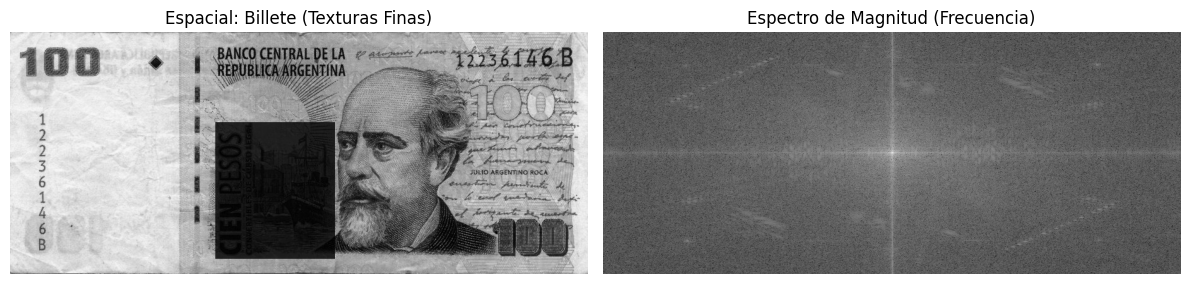

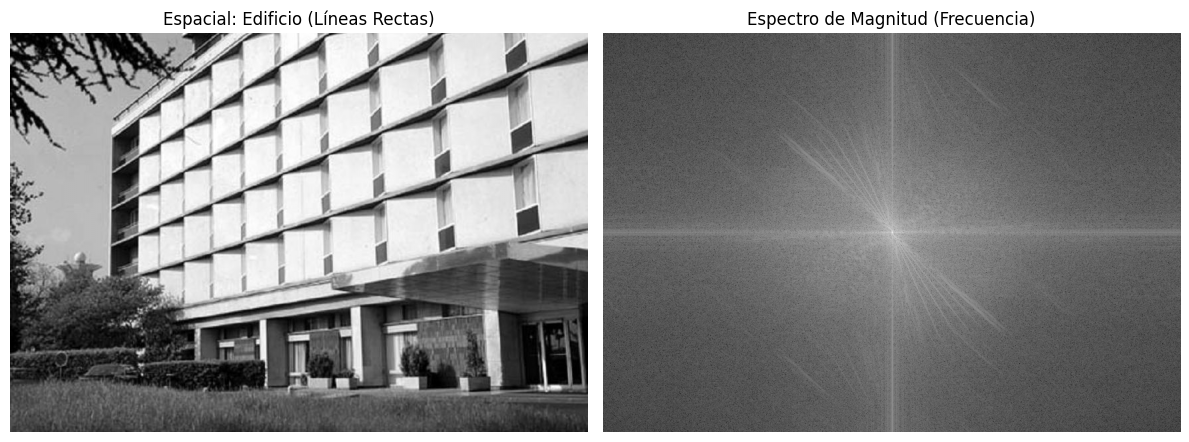

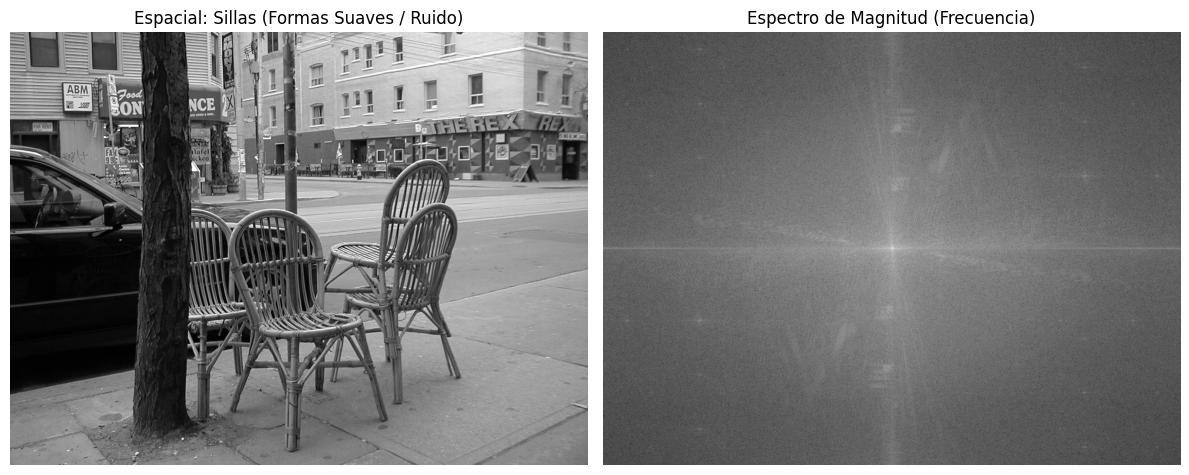

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analizar_espectro(img_path, titulo):
    # Cargar en escala de grises
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: No se encontró la imagen: {img_path}")
        return

    # 1. Calcular la TDF de la imagen real
    f = np.fft.fft2(img)
    
    # 2. Centrar las bajas frecuencias en el origen (el centro de la imagen)
    fshift = np.fft.fftshift(f)
    
    # 3. Calcular la magnitud (el módulo) y aplicar logaritmo para visualizar
    # Sumamos 1 para evitar problemas al hacer log(0)
    magnitud = 20 * np.log(np.abs(fshift) + 1)

    # Visualización
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    axs[0].imshow(img, cmap='gray')
    axs[0].set_title(f"Espacial: {titulo}")
    axs[0].axis('off')
    
    axs[1].imshow(magnitud, cmap='gray')
    axs[1].set_title("Espectro de Magnitud (Frecuencia)")
    axs[1].axis('off')
    
    plt.tight_layout()
    plt.show()

print("--- PUNTO 4: Correspondencia Frecuencial en Imágenes Reales ---")

# Ejecutamos el análisis para las 3 imágenes solicitadas
analizar_espectro('billete.jpg', 'Billete (Texturas Finas)')
analizar_espectro('building.jpg', 'Edificio (Líneas Rectas)')
analizar_espectro('chairs.jpg', 'Sillas (Formas Suaves / Ruido)')

**4. Componentes frecuenciales vs. Detalles de la imagen**
Al cargar imágenes reales, la correspondencia es la siguiente:
* **Bajas frecuencias (Centro del espectro):** Representan los cambios suaves de intensidad. Aquí vive la información del contraste general, la iluminación, los colores de fondo y las formas gruesas (siluetas).
* **Altas frecuencias (Alejadas del centro):** Representan los cambios bruscos de intensidad. Aquí se alojan los bordes de los objetos, las texturas finas, los detalles pequeños y el ruido de la imagen.

## EJERCICIO 2

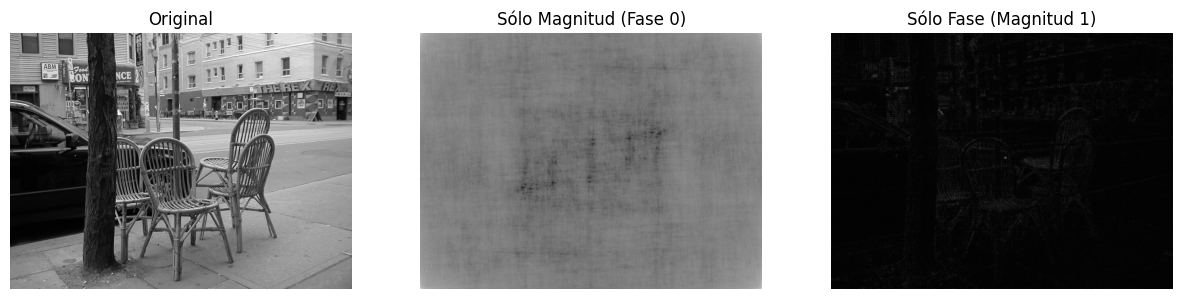

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen (puedes usar 'chairs.jpg' o cualquier otra de tu carpeta)
img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: No se encuentra la imagen.")
else:
    # 1. Calcular la TDF (Transformada Discreta de Fourier)
    f = np.fft.fft2(img)
    
    # 2. Obtener Magnitud y Fase
    magnitud = np.abs(f)
    fase = np.angle(f)
    
    # 3. Reconstrucción SÓLO con Magnitud (Fase = 0)
    # f_mag = magnitud * exp(j * 0) = magnitud
    f_solo_magnitud = magnitud * np.exp(1j * 0)
    img_solo_magnitud = np.abs(np.fft.ifft2(f_solo_magnitud))
    
    # 4. Reconstrucción SÓLO con Fase (Magnitud = 1)
    # f_fase = 1 * exp(j * fase)
    f_solo_fase = np.exp(1j * fase)
    img_solo_fase = np.abs(np.fft.ifft2(f_solo_fase))

    # Visualización
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    # Aplicamos logaritmo a la reconstrucción de magnitud para visualizar mejor la energía
    plt.imshow(np.log(img_solo_magnitud + 1), cmap='gray')
    plt.title('Sólo Magnitud (Fase 0)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_solo_fase, cmap='gray')
    plt.title('Sólo Fase (Magnitud 1)')
    plt.axis('off')
    
    plt.show()

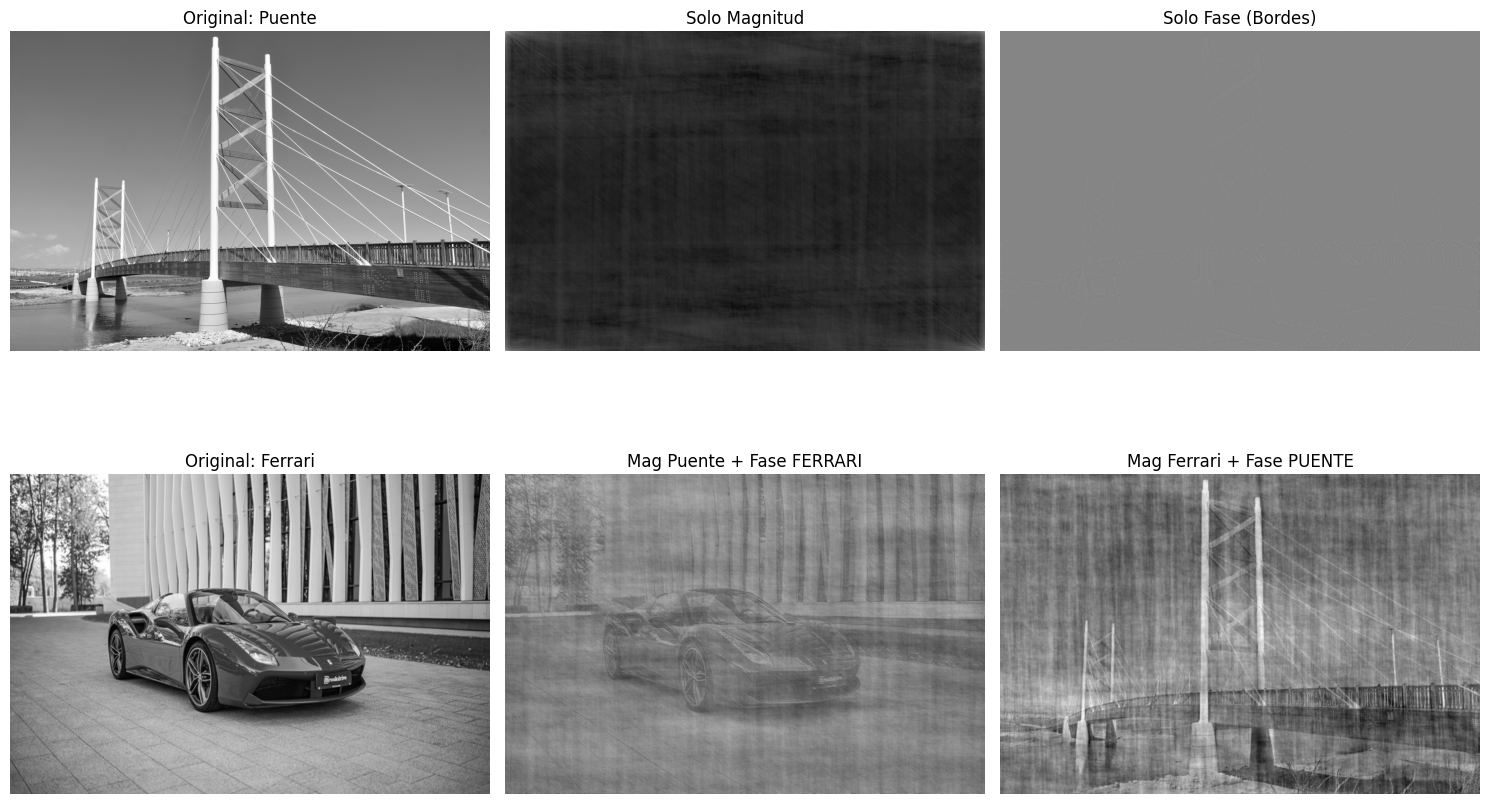

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def procesar_fase_magnitud():
    # Cargar imágenes (convertir a escala de grises y mismo tamaño para Oppenheim)
    img_p = cv2.imread('puente.jpg', cv2.IMREAD_GRAYSCALE)
    img_f = cv2.imread('ferrari.jpg', cv2.IMREAD_GRAYSCALE)
    
    if img_p is None or img_f is None:
        print("Error: no se encuentra'puente.jpg' y 'ferrari.jpg' en la carpeta.")
        return

    # Redimensionar el Ferrari al tamaño del puente para que coincidan las matrices
    img_f = cv2.resize(img_f, (img_p.shape[1], img_p.shape[0]))

    # --- PARTE 1: Reconstrucción Aislada (Puente) ---
    f_p = np.fft.fft2(img_p)
    mag_p, fase_p = np.abs(f_p), np.angle(f_p)

    # Reconstrucción solo magnitud (fase = 0)
    rec_mag = np.real(np.fft.ifft2(mag_p * np.exp(1j * 0)))
    
    # Reconstrucción solo fase (magnitud = 1)
    rec_fase = np.real(np.fft.ifft2(1.0 * np.exp(1j * fase_p)))

    # --- PARTE 2: Experimento de Oppenheim ---
    f_f = np.fft.fft2(img_f)
    mag_f, fase_f = np.abs(f_f), np.angle(f_f)

    # Mezcla A: Magnitud Puente + Fase Ferrari
    mezcla_a = np.real(np.fft.ifft2(mag_p * np.exp(1j * fase_f)))
    
    # Mezcla B: Magnitud Ferrari + Fase Puente
    mezcla_b = np.real(np.fft.ifft2(mag_f * np.exp(1j * fase_p)))

    # --- Visualización ---
    plt.figure(figsize=(15, 10))
    
    # Fila 1: Reconstrucciones aisladas
    plt.subplot(2, 3, 1); plt.imshow(img_p, cmap='gray'); plt.title('Original: Puente'); plt.axis('off')
    plt.subplot(2, 3, 2); plt.imshow(np.log(rec_mag + 1), cmap='gray'); plt.title('Solo Magnitud'); plt.axis('off')
    plt.subplot(2, 3, 3); plt.imshow(rec_fase, cmap='gray'); plt.title('Solo Fase (Bordes)'); plt.axis('off')

    # Fila 2: Oppenheim
    plt.subplot(2, 3, 4); plt.imshow(img_f, cmap='gray'); plt.title('Original: Ferrari'); plt.axis('off')
    plt.subplot(2, 3, 5); plt.imshow(mezcla_a, cmap='gray'); plt.title('Mag Puente + Fase FERRARI'); plt.axis('off')
    plt.subplot(2, 3, 6); plt.imshow(mezcla_b, cmap='gray'); plt.title('Mag Ferrari + Fase PUENTE'); plt.axis('off')

    plt.tight_layout()
    plt.show()

procesar_fase_magnitud()

### Respuestas al Ejercicio 2: Importancia de la fase

**1. Reconstrucción con componentes aisladas**
* **Solo Magnitud (Fase = 0):** La imagen resultante es una mancha de energía desenfocada e irreconocible. La magnitud aporta la distribución global de la iluminación y el contraste, pero al eliminar la fase, se pierde por completo la ubicación espacial de los píxeles y las formas de los objetos.
* **Solo Fase (Magnitud = 1):** La imagen reconstruida pierde su contraste original y parece un "mapa de bordes" o un dibujo a trazos, pero la estructura (por ejemplo, el puente o las sillas) es apenas reconocible. Esto demuestra que la fase es la responsable de conservar la geometría y los bordes.

**2. Experimento de Oppenheim**
Este experimento consiste en intercambiar los espectros de dos imágenes distintas, demostrando de forma empírica qué componente tiene más peso en la percepción humana:
* Al combinar la **Magnitud del Puente** con la **Fase del Ferrari**, la imagen resultante muestra claramente la forma del **Ferrari** (aunque con una iluminación o textura extraña heredada del puente).
* Al combinar la **Magnitud del Ferrari** con la **Fase del Puente**, el ojo humano percibe inmediatamente la estructura del **Puente**.
* **Conclusión fundamental:** En la percepción visual y en el procesamiento de imágenes, **la fase domina abrumadoramente sobre la magnitud**. Toda la información estructural, semántica y geométrica que hace que reconozcamos una imagen reside en su espectro de fase.

## EJERCICIO 3

--- PUNTOS 1, 2, 4 y 5: Comparativa de Filtros (Pasa-bajos y Pasa-altos) ---


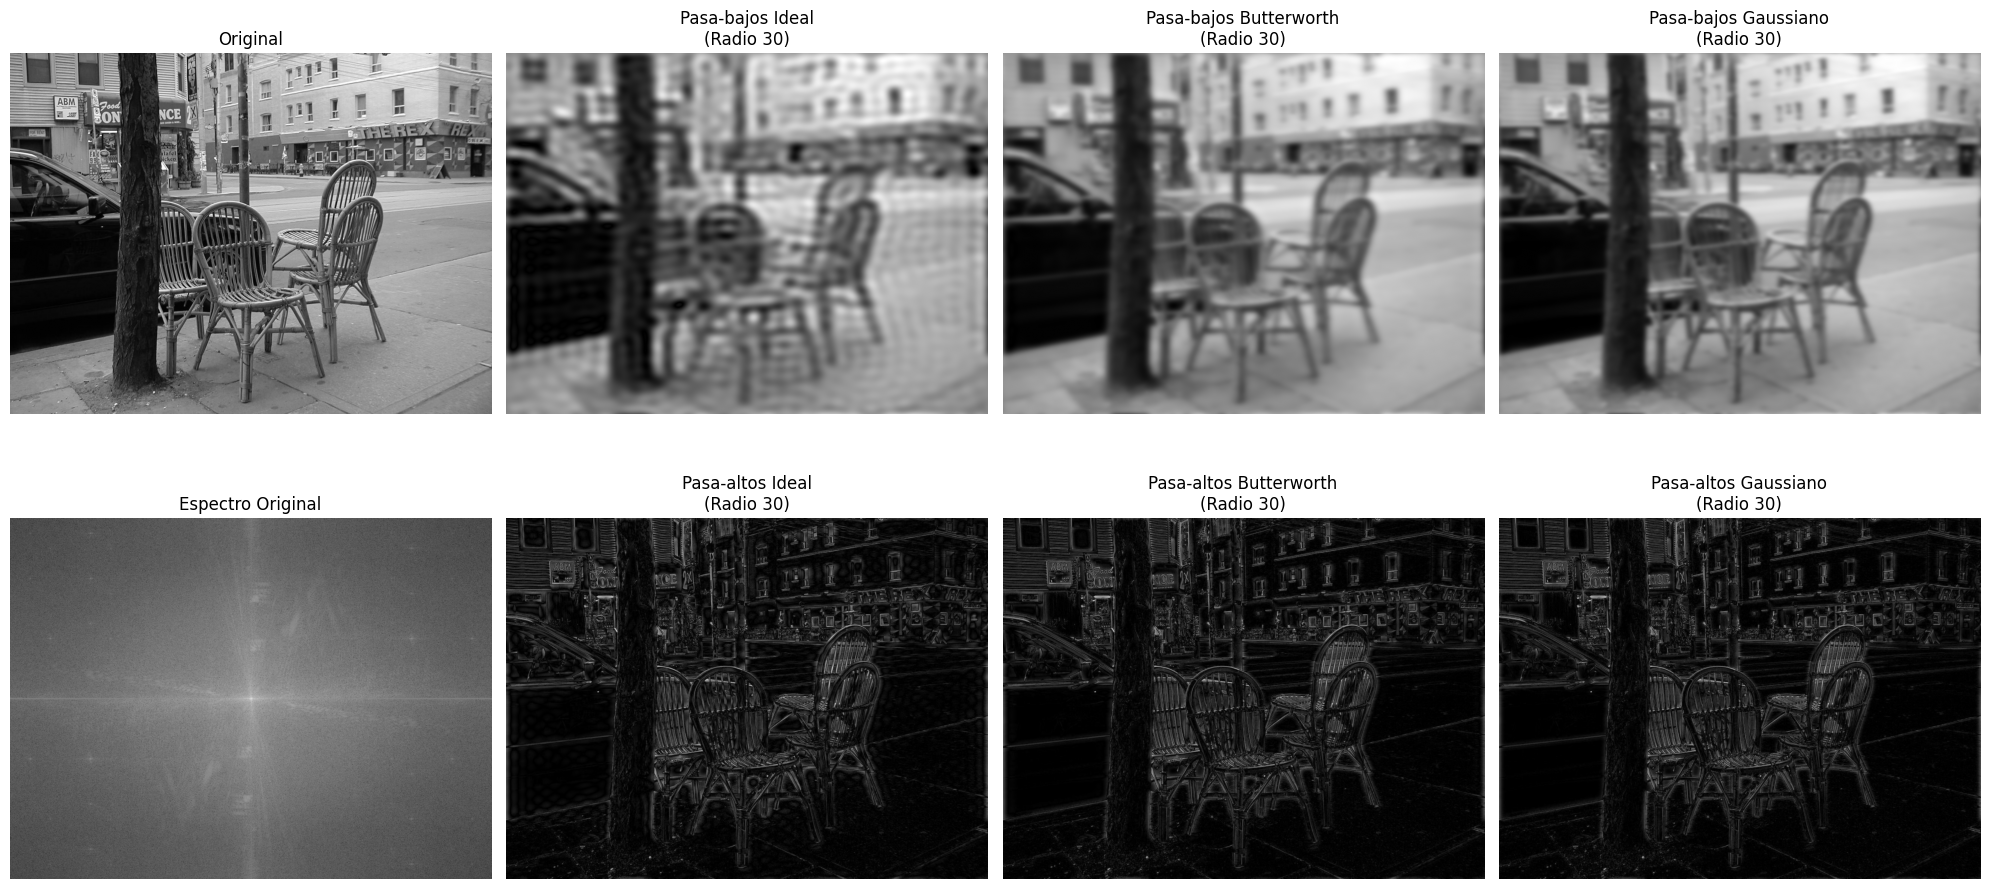

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crear_filtro_frecuencial(shape, radio, tipo='ideal', pasa_altos=False, n=2):
    """Genera filtros Ideal, Butterworth o Gaussiano directamente en frecuencia."""
    filas, columnas = shape
    centro_x, centro_y = filas // 2, columnas // 2
    
    # Crear una grilla de coordenadas
    x, y = np.ogrid[:filas, :columnas]
    # Calcular la distancia D(u,v) desde el centro
    distancia = np.sqrt((x - centro_x)**2 + (y - centro_y)**2)
    
    # Iniciar filtro base
    H = np.zeros((filas, columnas), dtype=np.float32)
    
    if tipo == 'ideal':
        H[distancia <= radio] = 1
    elif tipo == 'butterworth':
        # 1 / (1 + (D / D0)^(2n))
        H = 1 / (1 + (distancia / radio)**(2 * n))
    elif tipo == 'gaussiano':
        # exp(-D^2 / 2*(D0^2))
        H = np.exp(-(distancia**2) / (2 * (radio**2)))
        
    # Si es pasa-altos, invertimos el filtro (H_hp = 1 - H_lp)
    if pasa_altos:
        H = 1 - H
        
    return H

def aplicar_y_mostrar_filtro(img_path, radio=30):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"⚠️ Error: No se encontró la imagen '{img_path}'.")
        return
        
    # 1. Calcular TDF y centrar
    fshift = np.fft.fftshift(np.fft.fft2(img))
    
    tipos = ['ideal', 'butterworth', 'gaussiano']
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    
    # Referencia Original
    axs[0, 0].imshow(img, cmap='gray'); axs[0, 0].set_title('Original'); axs[0, 0].axis('off')
    axs[1, 0].imshow(np.log(np.abs(fshift)+1), cmap='gray'); axs[1, 0].set_title('Espectro Original'); axs[1, 0].axis('off')
    
    for i, tipo in enumerate(tipos):
        # Generar filtro PASA-BAJOS
        H_pb = crear_filtro_frecuencial(img.shape, radio, tipo=tipo, pasa_altos=False)
        # Aplicar filtro multiplicando elemento a elemento
        fshift_filtrado = fshift * H_pb
        # TDF Inversa
        img_pb = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtrado)))
        
        axs[0, i+1].imshow(img_pb, cmap='gray')
        axs[0, i+1].set_title(f'Pasa-bajos {tipo.capitalize()}\n(Radio {radio})')
        axs[0, i+1].axis('off')
        
        # Generar filtro PASA-ALTOS
        H_pa = crear_filtro_frecuencial(img.shape, radio, tipo=tipo, pasa_altos=True)
        fshift_filtrado_pa = fshift * H_pa
        img_pa = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtrado_pa)))
        
        axs[1, i+1].imshow(img_pa, cmap='gray')
        axs[1, i+1].set_title(f'Pasa-altos {tipo.capitalize()}\n(Radio {radio})')
        axs[1, i+1].axis('off')

    plt.tight_layout()
    plt.show()

print("--- PUNTOS 1, 2, 4 y 5: Comparativa de Filtros (Pasa-bajos y Pasa-altos) ---")
# Usamos 'chairs.jpg' u otra que tengas a mano. 
# Podés probar cambiando el radio a 10 (efecto extremo) o a 80 (efecto sutil).
aplicar_y_mostrar_filtro('chairs.jpg', radio=30)

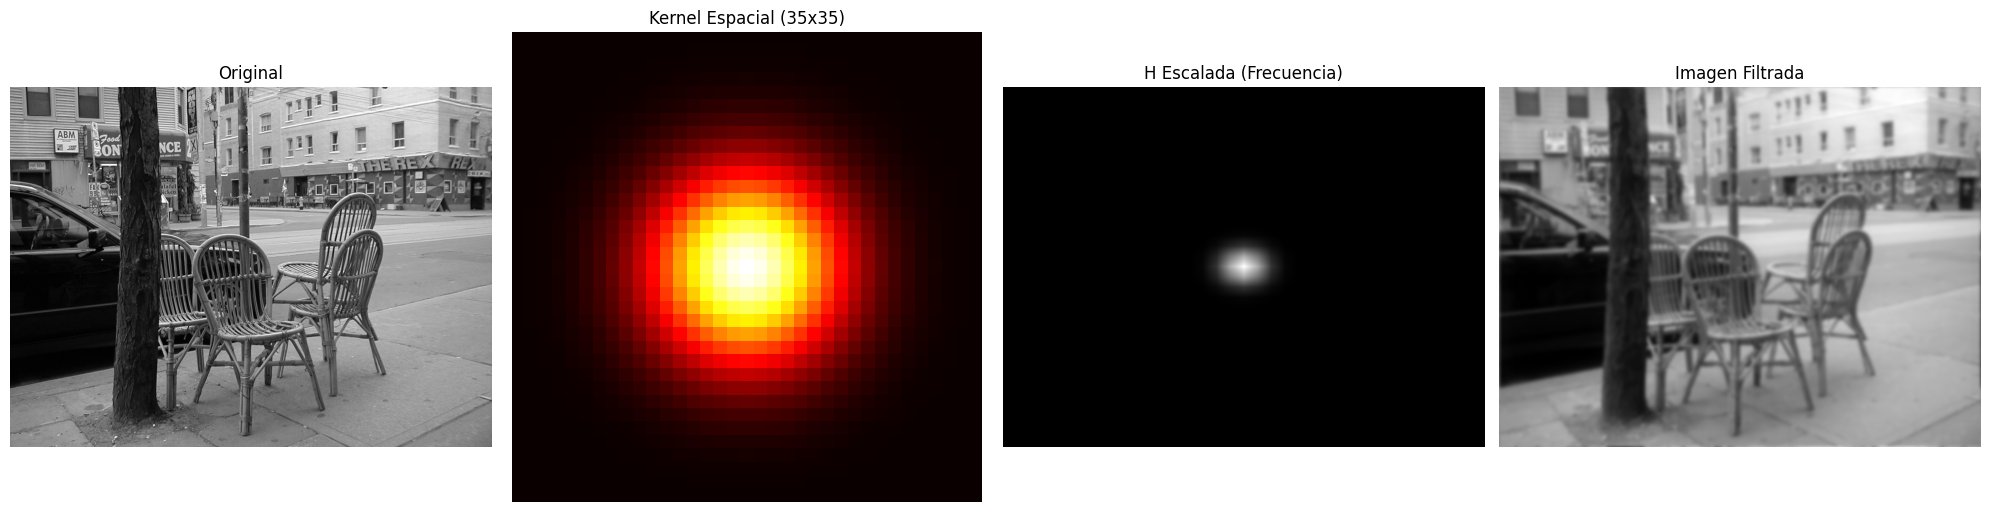

In [30]:
img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # 1. Definir kernel Gaussiano espacial (35x35)
    # GetGaussianKernel devuelve un array 1D, lo multiplicamos por su transpuesta para hacer el 2D
    k_1d = cv2.getGaussianKernel(35, sigma=5)
    kernel_espacial_35x35 = k_1d @ k_1d.T
    
    # 2. Obtener su respuesta en frecuencia (TDF del kernel chiquito)
    fft_kernel_chico = np.fft.fft2(kernel_espacial_35x35)
    fft_kernel_chico_shift = np.fft.fftshift(fft_kernel_chico)
    
    # 3. Escalar (resize) la magnitud del filtro frecuencial al tamaño de la imagen original
    # Usamos np.abs para quedarnos solo con la respuesta de amplitud
    H_escalado = cv2.resize(np.abs(fft_kernel_chico_shift), (img.shape[1], img.shape[0]))
    
    # Para que actúe como un filtro correcto (ganancia max 1), lo normalizamos
    H_escalado = H_escalado / np.max(H_escalado)
    
    # 4. Calcular la TDF de la imagen
    fshift_img = np.fft.fftshift(np.fft.fft2(img))
    
    # 5. Producto de transformadas (Filtrado)
    fshift_filtrado = fshift_img * H_escalado
    
    # 6. Transformada Inversa para recuperar la imagen
    img_filtrada = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtrado)))
    
    # Visualización
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    axs[0].imshow(img, cmap='gray'); axs[0].set_title('Original'); axs[0].axis('off')
    axs[1].imshow(kernel_espacial_35x35, cmap='hot'); axs[1].set_title('Kernel Espacial (35x35)'); axs[1].axis('off')
    axs[2].imshow(H_escalado, cmap='gray'); axs[2].set_title('H Escalada (Frecuencia)'); axs[2].axis('off')
    axs[3].imshow(img_filtrada, cmap='gray'); axs[3].set_title('Imagen Filtrada'); axs[3].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Error: No se encontró 'chairs.jpg'.")

### Conclusiones del Ejercicio 3: Filtros Pasa-bajos y Pasa-altos

**1. Filtro Pasa-bajos Ideal (Corte abrupto)**
* **Efecto:** Difumina la imagen al eliminar las altas frecuencias (bordes). 
* **Fenómeno de Gibbs:** Al tener un corte drástico (un cilindro perfecto en el espectro), genera ondas o un efecto de anillado (*ringing*) muy notorio alrededor de los bordes de los objetos en la imagen reconstruida. A menor radio de corte, mayor es el desenfoque y más severo el anillado.

**2. Filtro Pasa-bajos Butterworth (Transición suave)**
* **Efecto:** También difumina, pero introduce una transición suave dictada por el orden del filtro ($n$).
* **Fenómeno de Gibbs:** Se reduce drásticamente. En órdenes bajos (ej. $n=2$), el ringing es casi imperceptible, logrando un desenfoque mucho más natural que el filtro Ideal.

**3 y 4. Filtro Gaussiano (Espacial vs. Frecuencial)**
* **Efecto:** Produce el desenfoque más suave posible. La Transformada de Fourier de una campana de Gauss espacial es otra campana de Gauss en frecuencia.
* **Fenómeno de Gibbs:** Inexistente. Al no tener discontinuidades, no produce ningún tipo de anillado.
* **Espacial vs. Frecuencial (Comparativa):** Definir el filtro en el dominio espacial (35x35), calcular su TDF y escalarlo (`cv.resize`) funciona, pero la interpolación matemática al agrandar la matriz puede introducir ruidos o artefactos sutiles. Diseñar el filtro Gaussiano **directamente en el dominio de la frecuencia** (evaluando la ecuación en la grilla del tamaño exacto de la imagen) es más eficiente, computacionalmente más rápido y matemáticamente exacto.

**5. Filtros Pasa-altos**
* **Comportamiento:** Son el complemento matemático de los pasa-bajos ($H_{PA} = 1 - H_{PB}$). En lugar de difuminar, eliminan las zonas de color liso (bajas frecuencias) y resaltan únicamente los bordes y texturas finas.
* **Diferencias:** El Pasa-altos Ideal genera bordes con eco (ringing). El Gaussiano extrae los bordes de manera limpia y sin artefactos secundarios.

## EJERCICIO 4

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

def aplicar_filtro_homomorfico(img_path, gL, gH, D0, c):
    # Cargar la imagen
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"⚠️ Error: No se encontró la imagen '{img_path}'.")
        return

    # ---------------------------------------------------------
    # PIPELINE HOMOMÓRFICO: f -> ln -> F -> H -> F^-1 -> exp -> g
    # ---------------------------------------------------------
    # 1. Logaritmo natural (np.log1p equivale a log(1 + x) para evitar log(0))
    # Pasamos a float32 para no saturar valores
    img_log = np.log1p(np.float32(img))
    
    # 2. TDF y centrado
    fshift = np.fft.fftshift(np.fft.fft2(img_log))
    
    # 3. Generación del filtro H(u,v) (Gaussiano modificado)
    filas, columnas = img.shape
    x, y = np.ogrid[:filas, :columnas]
    centro_x, centro_y = filas // 2, columnas // 2
    
    # Distancia al cuadrado
    D2 = (x - centro_x)**2 + (y - centro_y)**2
    
    # Para evitar división por cero en el centro
    D0 = max(D0, 1e-5) 
    
    # Filtro Homomórfico: (gH - gL) * [1 - exp(-c * (D^2 / D0^2))] + gL
    H = (gH - gL) * (1 - np.exp(-c * (D2 / (D0**2)))) + gL
    
    # 4. Filtrado (Producto en frecuencia)
    fshift_filtrado = fshift * H
    
    # 5. TDF Inversa
    img_filtrada_log = np.real(np.fft.ifft2(np.fft.ifftshift(fshift_filtrado)))
    
    # 6. Exponencial (expm1 equivale a exp(x) - 1, revierte el log1p)
    img_filtrada = np.expm1(img_filtrada_log)
    
    # 7. Normalización a 0-255 uint8 para poder visualizar
    img_homomorfico = cv2.normalize(img_filtrada, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # ---------------------------------------------------------
    # COMPARATIVAS
    # ---------------------------------------------------------
    # Ecualización Clásica (Sobre la original)
    img_ecualizada = cv2.equalizeHist(img)
    
    # Homomórfico + Ecualización
    img_combo = cv2.equalizeHist(img_homomorfico)

    # ---------------------------------------------------------
    # VISUALIZACIÓN
    # ---------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    axs[0, 0].imshow(img, cmap='gray')
    axs[0, 0].set_title('1. Imagen Original (Iluminación pobre)')
    axs[0, 0].axis('off')
    
    axs[0, 1].imshow(img_ecualizada, cmap='gray')
    axs[0, 1].set_title('2. Ecualización Clásica\n(Suele "quemar" las zonas claras)')
    axs[0, 1].axis('off')
    
    axs[1, 0].imshow(img_homomorfico, cmap='gray')
    axs[1, 0].set_title(f'3. Filtro Homomórfico\n(Aclara sombras protegiendo brillos)')
    axs[1, 0].axis('off')
    
    axs[1, 1].imshow(img_combo, cmap='gray')
    axs[1, 1].set_title('4. Homomórfico + Ecualizada\n(El mejor resultado global)')
    axs[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


interact(aplicar_filtro_homomorfico,
         img_path=Dropdown(options=['casilla.tif', 'reunion.tif'], value='casilla.tif', description='Imagen:'),
         # Agregamos la "r" antes de las comillas en las descripciones
         gL=FloatSlider(min=0.0, max=1.0, step=0.1, value=0.3, description=r'Gamma L ', continuous_update=False),
         gH=FloatSlider(min=1.0, max=5.0, step=0.1, value=1.5, description=r'Gamma H ', continuous_update=False),
         D0=IntSlider(min=1, max=100, step=1, value=30, description=r'Corte ', continuous_update=False),
         c=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description=r'Constante ', continuous_update=False)
)

interactive(children=(Dropdown(description='Imagen:', options=('casilla.tif', 'reunion.tif'), value='casilla.t…

<function __main__.aplicar_filtro_homomorfico(img_path, gL, gH, D0, c)>

## EJERCICIO 5

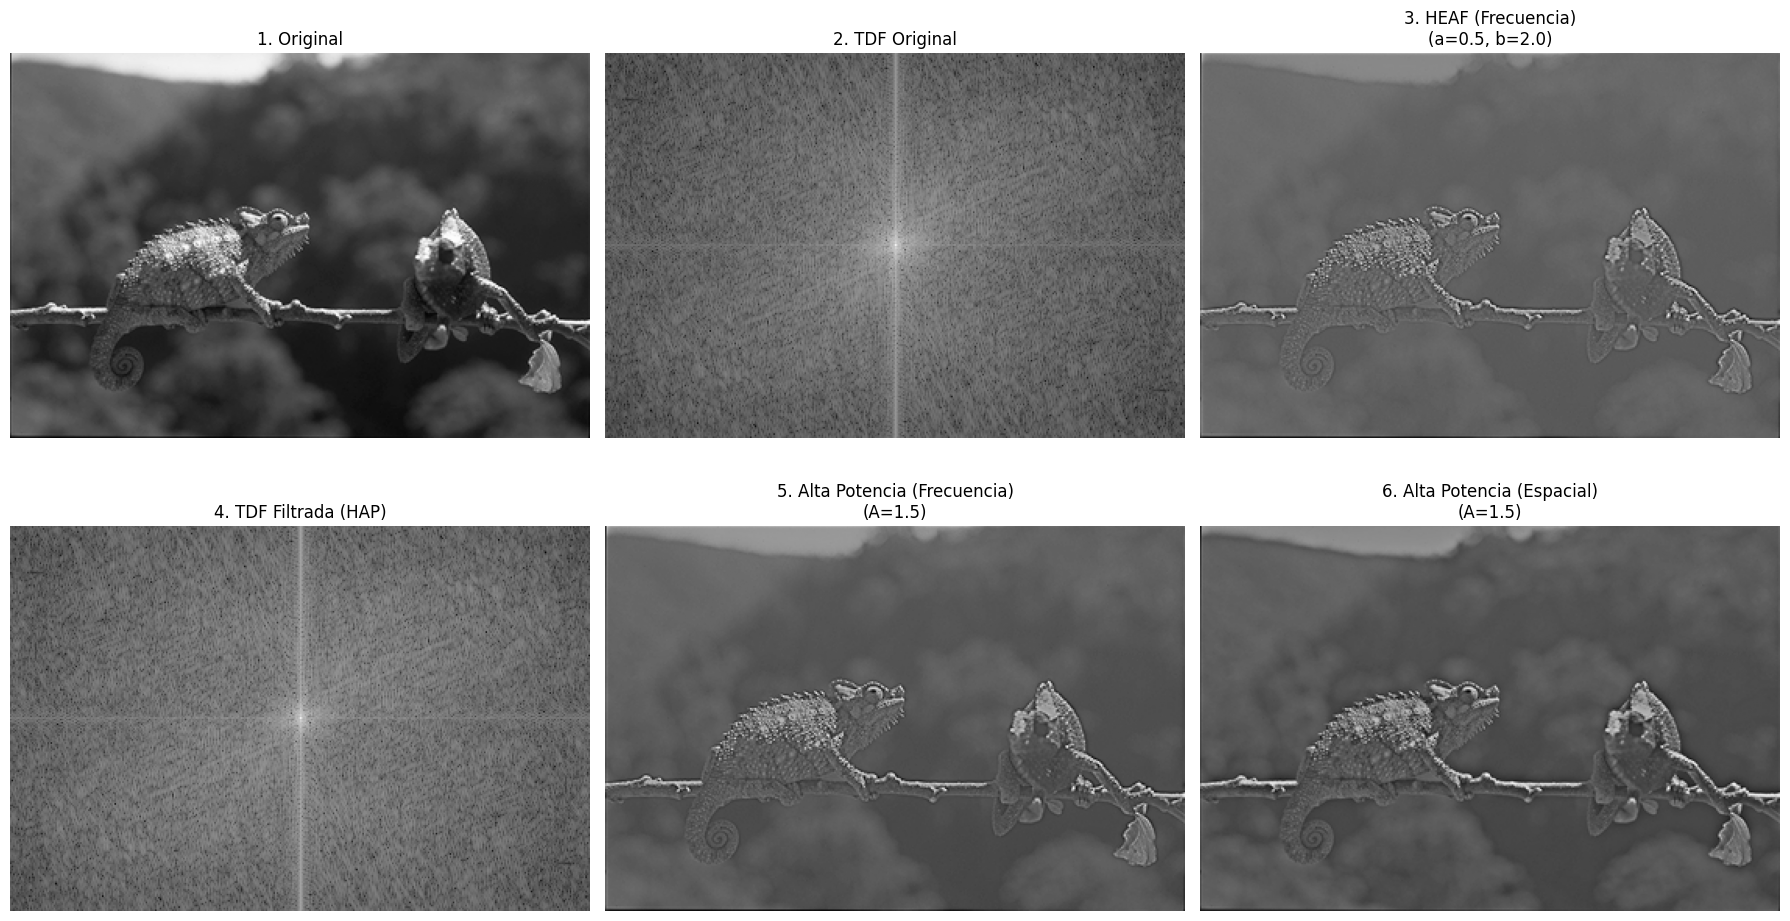

In [32]:

# 1. Cargar imagen
img = cv2.imread('camaleon.tif', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # 2. Calcular TDF y centrar
    fshift = np.fft.fftshift(np.fft.fft2(img))
    espectro_orig = np.log(np.abs(fshift) + 1)
    
    # 3. Crear Filtro Pasa-Altos Base (H_PA) - Usaremos un Gaussiano
    filas, columnas = img.shape
    x, y = np.ogrid[:filas, :columnas]
    centro_x, centro_y = filas // 2, columnas // 2
    D2 = (x - centro_x)**2 + (y - centro_y)**2
    
    D0 = 40  # Frecuencia de corte
    H_PB = np.exp(-D2 / (2 * (D0**2))) # Base Pasa-bajos
    H_PA = 1 - H_PB                    # Base Pasa-altos
    
    # ---------------------------------------------------------
    # 4. APLICAR FILTROS FRECUENCIALES
    # ---------------------------------------------------------
    # Filtro de Alta Potencia (HAP)
    A = 1.5
    H_AP = (A - 1) + H_PA
    img_HAP = np.real(np.fft.ifft2(np.fft.ifftshift(fshift * H_AP)))
    
    # Filtro de Énfasis de Alta Frecuencia (HEAF)
    a, b = 0.5, 2.0
    H_EAF = a + b * H_PA
    img_HEAF = np.real(np.fft.ifft2(np.fft.ifftshift(fshift * H_EAF)))
    
    # ---------------------------------------------------------
    # 5. FILTRO ESPACIAL (Para comparación Punto 3)
    # ---------------------------------------------------------
    # Espacial: f_AP = (A-1)*original + f_PA_espacial
    # Calculamos pasa-bajos espacial (difuminado)
    img_blur = cv2.GaussianBlur(img, (21, 21), 0)
    
    # Convertimos a float para evitar truncamientos en la resta
    img_float = np.float32(img)
    blur_float = np.float32(img_blur)
    
    # Pasa-altos espacial = Original - Blur
    f_PA_espacial = img_float - blur_float
    
    # Alta Potencia Espacial
    img_HAP_espacial = (A - 1) * img_float + f_PA_espacial
    
    # ---------------------------------------------------------
    # 6. NORMALIZACIÓN Y VISUALIZACIÓN
    # ---------------------------------------------------------
    # Normalizamos todo a 0-255 para graficar correctamente
    def normalizar(imagen):
        return cv2.normalize(imagen, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    # Fila 1: Imagen y Espectro Original + Énfasis Frecuencial
    axs[0, 0].imshow(img, cmap='gray'); axs[0, 0].set_title('1. Original'); axs[0, 0].axis('off')
    axs[0, 1].imshow(espectro_orig, cmap='gray'); axs[0, 1].set_title('2. TDF Original'); axs[0, 1].axis('off')
    axs[0, 2].imshow(normalizar(img_HEAF), cmap='gray'); axs[0, 2].set_title(f'3. HEAF (Frecuencia)\n(a={a}, b={b})'); axs[0, 2].axis('off')
    
    # Fila 2: Comparativa HAP Frecuencia vs Espacial
    # Mostramos el espectro del filtro HAP
    axs[1, 0].imshow(np.log(np.abs(fshift * H_AP) + 1), cmap='gray'); axs[1, 0].set_title('4. TDF Filtrada (HAP)'); axs[1, 0].axis('off')
    axs[1, 1].imshow(normalizar(img_HAP), cmap='gray'); axs[1, 1].set_title(f'5. Alta Potencia (Frecuencia)\n(A={A})'); axs[1, 1].axis('off')
    axs[1, 2].imshow(normalizar(img_HAP_espacial), cmap='gray'); axs[1, 2].set_title(f'6. Alta Potencia (Espacial)\n(A={A})'); axs[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Error: No se encontró la imagen 'camaleon.tif'.")

### Ejercicio 5: Filtros de acentuado en el dominio frecuencial

**1. Definición de las Funciones de Transferencia**
La idea central de estos filtros es sumar la imagen original (que contiene las bajas frecuencias) con el resultado de un filtro pasa-altos (que contiene los bordes).
* **Filtro de Alta Potencia (High-Boost - HAP):** $H_{AP} = (A - 1) + H_{PA}$
    Donde $A$ es un factor de amplificación ($A \ge 1$). La constante $(A-1)$ permite que pasen las bajas frecuencias (el fondo de la imagen). Si $A=1$, se comporta como un pasa-altos puro. Si $A > 1$, se recupera la imagen original pero con los bordes sumados.
* **Filtro de Énfasis de Alta Frecuencia (HEAF):**
    $H_{EAF} = a + b \cdot H_{PA}$
    Es una versión más flexible. La constante $a$ controla cuánta iluminación de fondo se retiene (suele ser $< 1$), y la constante $b$ controla cuánto se amplifican los bordes.

**3. Comparativa: Alta Potencia en Frecuencia vs. Espacial**
Matemáticamente, ambos métodos son equivalentes. 
* En el **dominio espacial**, la Alta Potencia se calcula restando una versión difuminada (pasa-bajos) a la original amplificada: $f_{AP} = A \cdot f(x,y) - f_{PB}(x,y)$.
* En el **dominio frecuencial**, es una simple multiplicación matricial punto a punto.
* **Diferencia práctica:** El método espacial es más rápido computacionalmente para núcleos (kernels) pequeños (ej. 3x3). Sin embargo, el método frecuencial es más preciso, no sufre de artefactos de borde y permite un control absoluto y suave sobre la frecuencia de corte sin importar el tamaño equivalente del kernel.

## EJERCICIO 6

--- EJERCICIO 6.1: Benchmark de FFT y Agregado de Ceros ---
Tamaño Original: 247x372
Tamaño Óptimo (FFT): 250x375
Tamaño Subóptimo: 249x374

--- RESULTADOS DE TIEMPO ---
TDF Original: 5.01 ms
FFT Óptima:   2.95 ms 
FFT Subóptima: 6.14 ms 


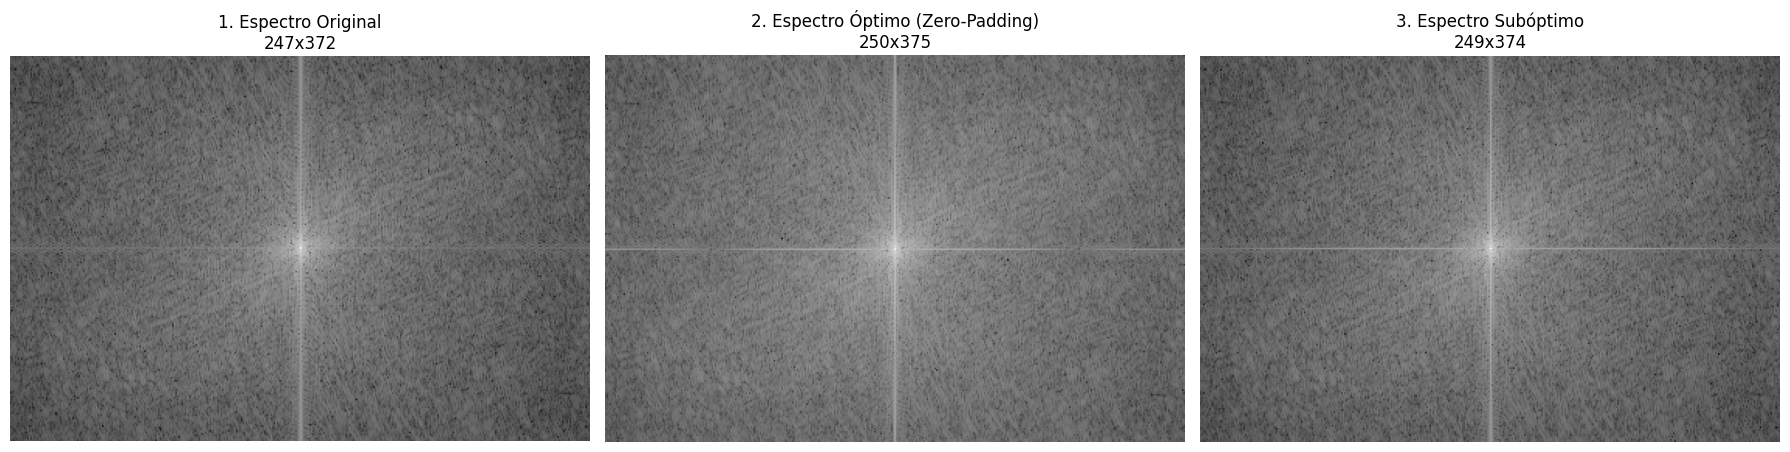

In [ ]:
import cv2
import numpy as np
import timeit
import matplotlib.pyplot as plt

print("--- EJERCICIO 6.1: Benchmark de FFT y Agregado de Ceros ---")

# Cargamos una imagen grande para que el tiempo sea notorio
img = cv2.imread('camaleon.tif', cv2.IMREAD_GRAYSCALE)

if img is not None:
    filas, columnas = img.shape
    print(f"Tamaño Original: {filas}x{columnas}")
    
    # 1. Obtener tamaño óptimo
    filas_opt = cv2.getOptimalDFTSize(filas)
    col_opt = cv2.getOptimalDFTSize(columnas)
    print(f"Tamaño Óptimo (FFT): {filas_opt}x{col_opt}")
    
    # 2. Imagen Óptima (Agregando ceros a la derecha y abajo)
    img_opt = cv2.copyMakeBorder(img, 0, filas_opt - filas, 0, col_opt - columnas, 
                                 cv2.BORDER_CONSTANT, value=0)
    
    # 3. Imagen Subóptima (Óptimo - 1)
    filas_sub = filas_opt - 1
    col_sub = col_opt - 1
    print(f"Tamaño Subóptimo: {filas_sub}x{col_sub}")
    img_sub = cv2.copyMakeBorder(img, 0, filas_sub - filas, 0, col_sub - columnas, 
                                 cv2.BORDER_CONSTANT, value=0)
    
    # --- MEDICIÓN DE TIEMPOS ---
    def medir_tiempo_fft(imagen, iteraciones=50):
        # Medimos varias veces para tener un promedio real
        inicio = timeit.default_timer()
        for _ in range(iteraciones):
            _ = np.fft.fft2(imagen)
        fin = timeit.default_timer()
        return ((fin - inicio) / iteraciones) * 1000 # En milisegundos

    t_orig = medir_tiempo_fft(img)
    t_opt = medir_tiempo_fft(img_opt)
    t_sub = medir_tiempo_fft(img_sub)

    print("\n--- RESULTADOS DE TIEMPO ---")
    print(f"TDF Original: {t_orig:.2f} ms")
    print(f"FFT Óptima:   {t_opt:.2f} ms ")
    print(f"FFT Subóptima: {t_sub:.2f} ms ")

    # --- VISUALIZACIÓN ---
    def obtener_espectro(imagen):
        fshift = np.fft.fftshift(np.fft.fft2(imagen))
        return np.log(np.abs(fshift) + 1)

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    axs[0].imshow(obtener_espectro(img), cmap='gray')
    axs[0].set_title(f"1. Espectro Original\n{filas}x{columnas}")
    axs[0].axis('off')
    
    axs[1].imshow(obtener_espectro(img_opt), cmap='gray')
    axs[1].set_title(f"2. Espectro Óptimo (Zero-Padding)\n{filas_opt}x{col_opt}")
    axs[1].axis('off')
    
    axs[2].imshow(obtener_espectro(img_sub), cmap='gray')
    axs[2].set_title(f"3. Espectro Subóptimo\n{filas_sub}x{col_sub}")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("Error: No se encontró 'camaleon.tif'.")

Ángulo detectado mediante Hough: -13.05 grados


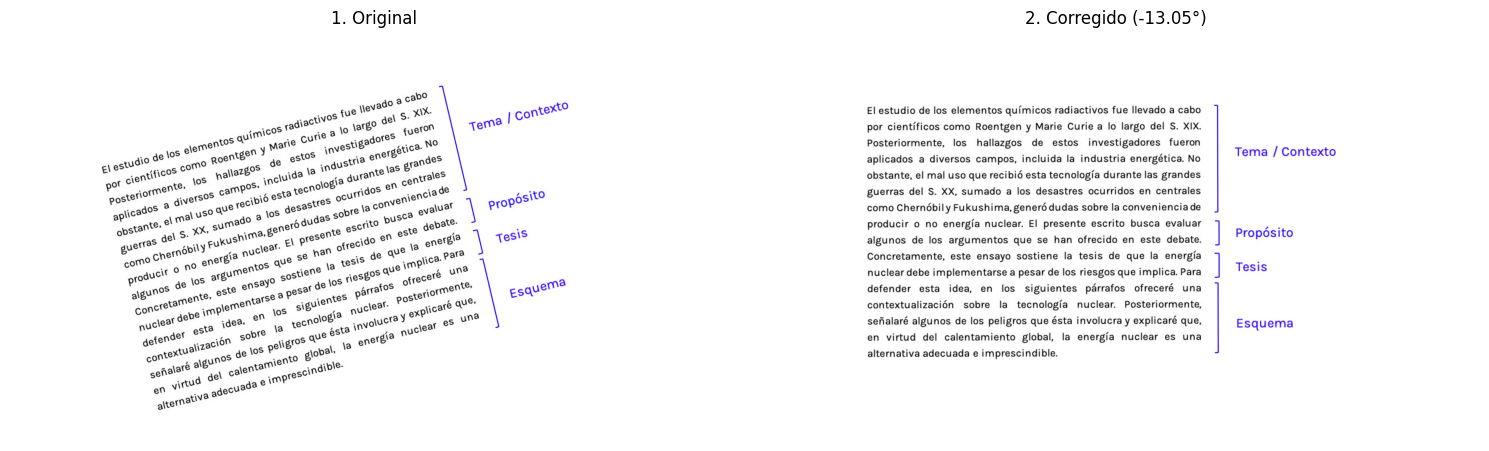

Ángulo detectado mediante Hough: 0.00 grados


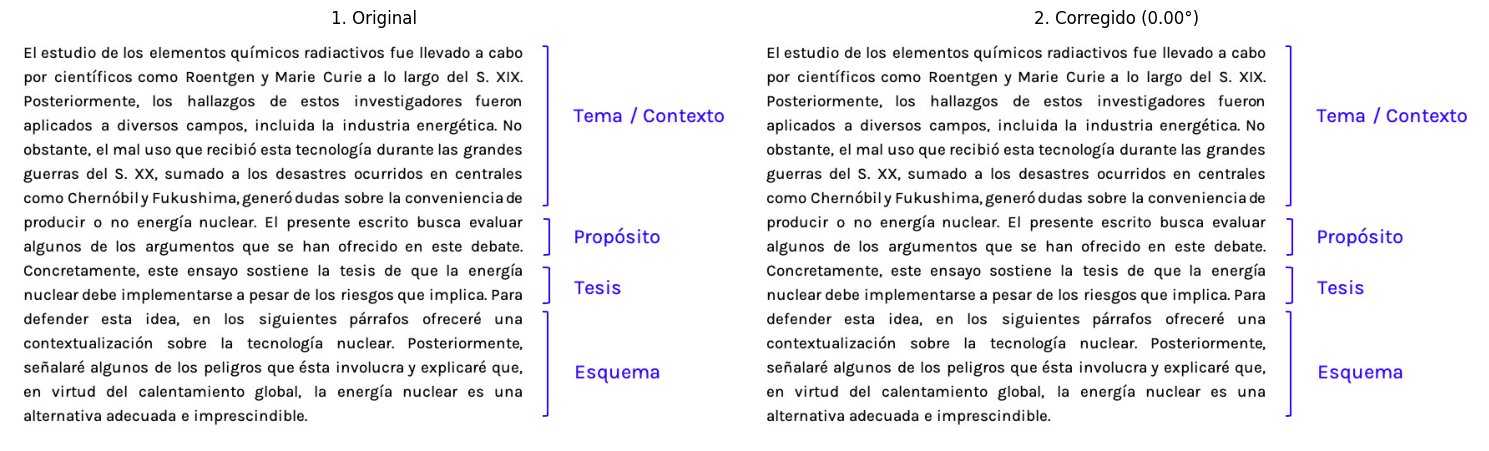

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def corregir_rotacion_texto(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: No se encontró '{img_path}'.")
        return
        
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Detectar bordes para identificar las líneas del texto
    # Usamos Canny para extraer las formas del texto
    edges = cv2.Canny(img_gris, 50, 150, apertureSize=3)
    
    # 2. Transformada de Hough para detectar segmentos de línea
    # minLineLength debe ser lo suficientemente grande para capturar palabras/líneas
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10)
    
    if lines is None:
        print("No se pudieron detectar líneas para alinear.")
        return

    # 3. Calcular los ángulos de todas las líneas detectadas
    angulos = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Calcular el ángulo en grados
        angulo = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        # Filtramos ángulos extremos (solo queremos líneas casi horizontales)
        if abs(angulo) < 45: 
            angulos.append(angulo)
            
    if not angulos:
        print("No se encontraron ángulos válidos.")
        return

    # 4. Usamos la mediana para ignorar líneas sueltas o ruido
    angulo_mediano = np.median(angulos)
    print(f"Ángulo detectado mediante Hough: {angulo_mediano:.2f} grados")
    
    # 5. Rotar la imagen
    (alto, ancho) = img.shape[:2]
    centro = (ancho // 2, alto // 2)
    
    # Generamos la matriz de rotación
    M = cv2.getRotationMatrix2D(centro, angulo_mediano, 1.0)
    
    # Aplicamos la rotación
    img_rotada = cv2.warpAffine(img, M, (ancho, alto), 
                                flags=cv2.INTER_CUBIC, 
                                borderMode=cv2.BORDER_REPLICATE)
    
    # Visualización
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axs[0].set_title("1. Original")
    axs[0].axis('off')
    
    axs[1].imshow(cv2.cvtColor(img_rotada, cv2.COLOR_BGR2RGB))
    axs[1].set_title(f"2. Corregido ({angulo_mediano:.2f}°)")
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()


corregir_rotacion_texto('parrafo0.jpg')
corregir_rotacion_texto('parrafo1.jpg')
